In [1]:
import jax.numpy as jnp
import jax
import matplotlib.pyplot as plt
from amplitude import get_amplitude_interpolant

In [2]:
amp_interp, psi_r, delta_psi_r = get_amplitude_interpolant(
    "./high-ecc-schw/amplitude_mag_phase.h5",
    interp_type='mag-phase'
)

In [3]:
from trajectory import get_trajectory_generator
traj_gen = get_trajectory_generator(
    "./high-ecc-schw/fluxes.h5",
    atol=1e-13,
    rtol=0,
    )
    

/Users/c.chapman-bird@bham.ac.uk/miniconda3/envs/few-generic-redo/lib/python3.12/site-packages/lisaconstants/compat/astropy.py:252: UserWarning: The following constants differ between lisaconstants and the version of astropy you have installed: VACUUM_PERMEABILITY. The recommended version of astropy is 7.1.0. Use a different one at your own risks. 
You may also open an issue at https://gitlab.esa.int/lisa-sgs/commons/lisa-constants to warn that lisaconstants is not compatible with astropy v8.0.0
  warnings.warn(


In [4]:
m1 = 1e5
m2 = 1e1
p0 = 10.0
e0 = 0.9

sol = traj_gen(
    m1,
    m2,
    p0,
    e0,
    0.0,
    0.0,
    1
)

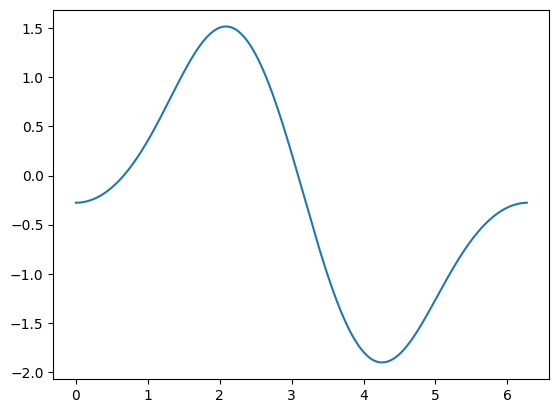

In [20]:
plt.plot(psi_r, amp_interp(13.0, 0.4)[1])

In [5]:
mag_along_traj, phase_along_traj = jax.vmap(amp_interp, in_axes=(0, 0))(sol.ys[:,0], sol.ys[:,1])

In [6]:
trunc_ind = sol.stats["num_accepted_steps"]
trunc_ind

Array(131, dtype=int64, weak_type=True)

Text(0, 0.5, '$\\psi_r$')

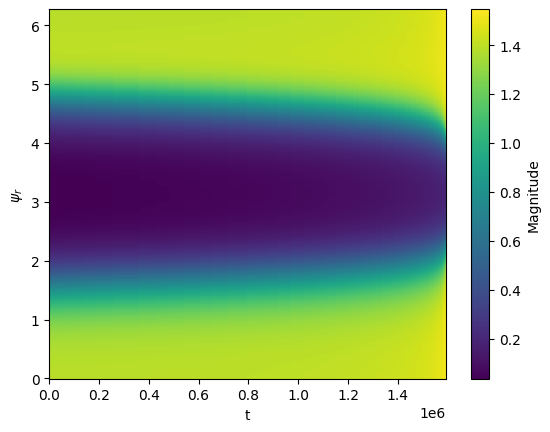

In [11]:
plt.pcolormesh(sol.ts[:trunc_ind], psi_r, mag_along_traj[:trunc_ind].T, shading='auto')
plt.colorbar(label=r"Magnitude")
plt.xlabel("t")
plt.ylabel(r"$\psi_r$")

Text(0, 0.5, '$\\psi_r$')

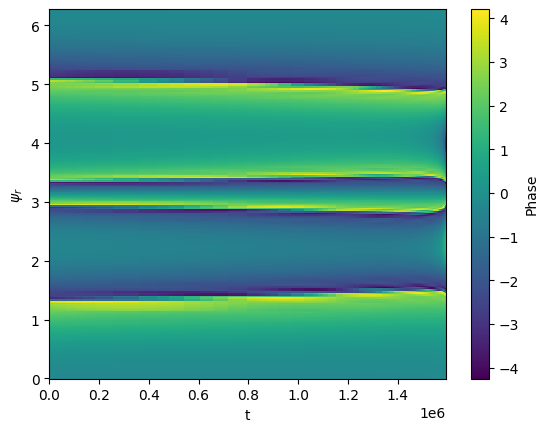

In [10]:
plt.pcolormesh(sol.ts[:trunc_ind], psi_r, phase_along_traj[:trunc_ind].T, shading='auto')
plt.colorbar(label=r"Phase")
plt.xlabel("t")
plt.ylabel(r"$\psi_r$")

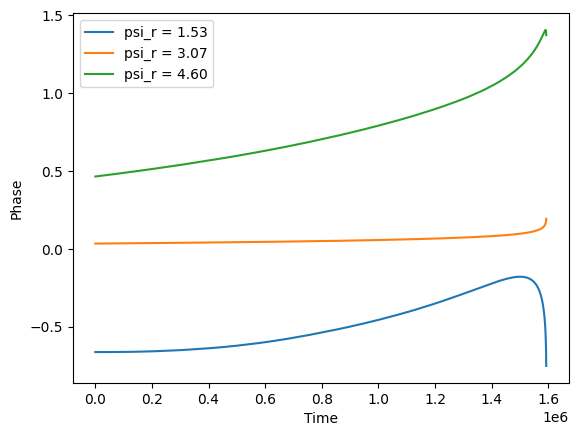

In [14]:
psi_r_points = jnp.array([125, 250, 375])
for psir_p in psi_r_points:
    plt.plot(sol.ts, phase_along_traj[:, psir_p], label=f'psi_r = {psi_r[psir_p]:.2f}')
plt.xlabel('Time')
plt.ylabel('Phase')
plt.legend()